# 19_E11 - Mapeo de clases axiales y reporte final

Notebook de cierre documental del módulo axial T2.

Objetivos:
- Cargar outputs de E8, E9 y E10.
- Construir tabla de clases axiales.
- Calcular distribución de clases del subset T2 curado.
- Resumir métricas finales con y sin raw_0.
- Generar reporte Markdown/JSON para tesis.

Nota: usar como guía el script `backlogProducto/scripts/E11_axial_class_mapping_and_final_report.py` si se agrega luego.


Imports, rutas e inputs

In [3]:
%pip install pydicom
%pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.2 MB/s eta 0:00:00


In [4]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

PFI_ROOT = Path("/content/drive/MyDrive/PFI_MVP")

E8_ROOT = PFI_ROOT / "results" / "E8_alkafri_official_pairing"
E9_ROOT = PFI_ROOT / "results" / "E9_alkafri_axial_t2_final_labels_baseline"
E10_ROOT = PFI_ROOT / "results" / "E10_axial_t2_final_training_clean"
E11_ROOT = PFI_ROOT / "results" / "E11_axial_class_mapping_final_report"

FIGURES_ROOT = PFI_ROOT / "figures"
DOCS_ROOT = PFI_ROOT / "docs"

for p in [E11_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

CAND_PATH = E8_ROOT / "E8_FINAL_LABELS_FIXED_3_candidates.csv"
SPLIT_PATH = E9_ROOT / "E9_t2_final_labels_curated_split.csv"
VAL_E10_PATH = E10_ROOT / "E10_val_metrics.json"
TEST_E10_PATH = E10_ROOT / "E10_test_metrics.json"
REPORT_E10_PATH = E10_ROOT / "E10_axial_t2_final_training_clean_report.json"

required = [CAND_PATH, SPLIT_PATH, VAL_E10_PATH, TEST_E10_PATH, REPORT_E10_PATH]

for p in required:
    print(p, "->", p.exists())
    assert p.exists(), f"Falta archivo requerido: {p}"

print("E11_ROOT:", E11_ROOT)


Mounted at /content/drive
/content/drive/MyDrive/PFI_MVP/results/E8_alkafri_official_pairing/E8_FINAL_LABELS_FIXED_3_candidates.csv -> True
/content/drive/MyDrive/PFI_MVP/results/E9_alkafri_axial_t2_final_labels_baseline/E9_t2_final_labels_curated_split.csv -> True
/content/drive/MyDrive/PFI_MVP/results/E10_axial_t2_final_training_clean/E10_val_metrics.json -> True
/content/drive/MyDrive/PFI_MVP/results/E10_axial_t2_final_training_clean/E10_test_metrics.json -> True
/content/drive/MyDrive/PFI_MVP/results/E10_axial_t2_final_training_clean/E10_axial_t2_final_training_clean_report.json -> True
E11_ROOT: /content/drive/MyDrive/PFI_MVP/results/E11_axial_class_mapping_final_report


Tabla de clases axiales

In [5]:
class_rows = [
    {
        "class_id": 0,
        "raw_value": 250,
        "nombre_interno": "background_250",
        "uso_en_metricas": "no",
        "grupo_reporte": "fondo",
        "observacion": "Fondo del label final.",
    },
    {
        "class_id": 1,
        "raw_value": 0,
        "nombre_interno": "raw_0",
        "uso_en_metricas": "opcional",
        "grupo_reporte": "clase_minoritaria_problemática",
        "observacion": "Clase de bajo rendimiento relativo. Se reporta, pero también se calculan métricas excluyéndola.",
    },
    {
        "class_id": 2,
        "raw_value": 50,
        "nombre_interno": "raw_50",
        "uso_en_metricas": "sí",
        "grupo_reporte": "clase_principal",
        "observacion": "Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.",
    },
    {
        "class_id": 3,
        "raw_value": 100,
        "nombre_interno": "raw_100",
        "uso_en_metricas": "sí",
        "grupo_reporte": "clase_principal",
        "observacion": "Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.",
    },
    {
        "class_id": 4,
        "raw_value": 150,
        "nombre_interno": "raw_150",
        "uso_en_metricas": "sí",
        "grupo_reporte": "clase_principal",
        "observacion": "Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.",
    },
    {
        "class_id": 5,
        "raw_value": 200,
        "nombre_interno": "raw_200",
        "uso_en_metricas": "sí",
        "grupo_reporte": "clase_principal",
        "observacion": "Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.",
    },
]

class_df = pd.DataFrame(class_rows)
class_df.to_csv(E11_ROOT / "E11_axial_class_mapping.csv", index=False)

display(class_df)
print("Guardado:", E11_ROOT / "E11_axial_class_mapping.csv")

,class_id,raw_value,nombre_interno,uso_en_metricas,grupo_reporte,observacion
0,0,250,background_250,no,fondo,Fondo del label final.
1,1,0,raw_0,opcional,clase_minoritaria_problemática,"Clase de bajo rendimiento relativo. Se reporta, pero también se calculan métricas excluyéndola."
2,2,50,raw_50,sí,clase_principal,Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.
3,3,100,raw_100,sí,clase_principal,Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.
4,4,150,raw_150,sí,clase_principal,Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.
5,5,200,raw_200,sí,clase_principal,Clase anatómica codificada por el dataset. Nombre clínico pendiente de corroboración documental.


Guardado: /content/drive/MyDrive/PFI_MVP/results/E11_axial_class_mapping_final_report/E11_axial_class_mapping.csv


Distribución de clases en los 610 pares T2

In [6]:
RAW_VALUES = np.array([0, 50, 100, 150, 200, 250], dtype=np.int16)

RAW_TO_CLASS = {
    250: 0,
    0: 1,
    50: 2,
    100: 3,
    150: 4,
    200: 5,
}

CLASS_NAMES = dict(zip(class_df.class_id, class_df.nombre_interno))


def read_label_raw(path):
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.int16)


def label_to_class_map(path):
    arr = read_label_raw(path)
    flat = arr.reshape(-1)

    snapped = RAW_VALUES[
        np.abs(flat[:, None] - RAW_VALUES[None, :]).argmin(axis=1)
    ].reshape(arr.shape)

    y = np.zeros_like(snapped, dtype=np.uint8)

    for raw_value, class_id in RAW_TO_CLASS.items():
        y[snapped == raw_value] = class_id

    return y


split_df = pd.read_csv(SPLIT_PATH)
split_df = split_df[split_df["modality"].astype(str).eq("T2")].copy()
split_df["case_id_norm"] = split_df["case_id_norm"].astype(str).str.zfill(4)

print("Pares T2 curados:", len(split_df))
display(
    split_df.groupby("split")
    .agg(n=("case_id_norm", "size"), cases=("case_id_norm", "nunique"))
    .reset_index()
)

rows = []

for _, r in tqdm(split_df.iterrows(), total=len(split_df), desc="Distribución de clases"):
    y = label_to_class_map(r["final_label_file_path"])
    total_pixels = int(y.size)

    for class_id in range(6):
        pixels = int((y == class_id).sum())
        rows.append(
            {
                "case_id_norm": r["case_id_norm"],
                "disc_id": int(r["disc_id"]),
                "split": r["split"],
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "pixels": pixels,
                "ratio": pixels / total_pixels,
                "present": pixels > 0,
            }
        )

dist_long = pd.DataFrame(rows)
dist_long.to_csv(E11_ROOT / "E11_axial_class_distribution_long.csv", index=False)

dist_summary = (
    dist_long.groupby(["class_id", "class_name"])
    .agg(
        total_pixels=("pixels", "sum"),
        mean_ratio=("ratio", "mean"),
        median_ratio=("ratio", "median"),
        images_present=("present", "sum"),
        n_images=("present", "size"),
    )
    .reset_index()
)

dist_summary["presence_pct"] = dist_summary["images_present"] / dist_summary["n_images"]
dist_summary.to_csv(E11_ROOT / "E11_axial_class_distribution_summary.csv", index=False)

by_split = (
    dist_long.groupby(["split", "class_id", "class_name"])
    .agg(
        total_pixels=("pixels", "sum"),
        mean_ratio=("ratio", "mean"),
        images_present=("present", "sum"),
        n_images=("present", "size"),
    )
    .reset_index()
)

by_split["presence_pct"] = by_split["images_present"] / by_split["n_images"]
by_split.to_csv(E11_ROOT / "E11_axial_class_distribution_by_split.csv", index=False)

print("Resumen general:")
display(dist_summary)

print("Resumen por split:")
display(by_split)

Pares T2 curados: 610


,split,n,cases
0,test,102,29
1,train,427,128
2,val,81,27


Distribución de clases:   0%|          | 0/610 [00:00<?, ?it/s]

Resumen general:


,class_id,class_name,total_pixels,mean_ratio,median_ratio,images_present,n_images,presence_pct
0,0,background_250,58552746,0.937816,0.938667,610,610,1.000000
1,1,raw_0,149933,0.002401,0.000000,109,610,0.178689
2,2,raw_50,2209861,0.035394,0.034951,610,610,1.000000
3,3,raw_100,978912,0.015679,0.015591,610,610,1.000000
4,4,raw_150,198153,0.003173,0.003179,610,610,1.000000
5,5,raw_200,345595,0.005536,0.005283,610,610,1.000000


Resumen por split:


,split,class_id,class_name,total_pixels,mean_ratio,images_present,n_images,presence_pct
0,test,0,background_250,9775097,0.935882,102,102,1.000000
1,test,1,raw_0,20504,0.001963,21,102,0.205882
2,test,2,raw_50,388250,0.037172,102,102,1.000000
3,test,3,raw_100,169576,0.016235,102,102,1.000000
4,test,4,raw_150,32936,0.003153,102,102,1.000000
5,test,5,raw_200,58437,0.005595,102,102,1.000000
6,train,0,background_250,41019478,0.938541,427,427,1.000000
7,train,1,raw_0,109340,0.002502,71,427,0.166276
8,train,2,raw_50,1529936,0.035005,427,427,1.000000
9,train,3,raw_100,670404,0.015339,427,427,1.000000


Métricas finales E10

In [7]:
val_metrics = json.loads(VAL_E10_PATH.read_text(encoding="utf-8"))
test_metrics = json.loads(TEST_E10_PATH.read_text(encoding="utf-8"))
e10_report = json.loads(REPORT_E10_PATH.read_text(encoding="utf-8"))

metrics_summary = pd.DataFrame(
    [
        ["val", "dice_macro_no_bg", val_metrics["dice_macro_no_bg"]],
        ["val", "iou_macro_no_bg", val_metrics["iou_macro_no_bg"]],
        ["val", "dice_macro_excluding_raw0", val_metrics["dice_macro_excluding_raw0"]],
        ["val", "iou_macro_excluding_raw0", val_metrics["iou_macro_excluding_raw0"]],
        ["test", "dice_macro_no_bg", test_metrics["dice_macro_no_bg"]],
        ["test", "iou_macro_no_bg", test_metrics["iou_macro_no_bg"]],
        ["test", "dice_macro_excluding_raw0", test_metrics["dice_macro_excluding_raw0"]],
        ["test", "iou_macro_excluding_raw0", test_metrics["iou_macro_excluding_raw0"]],
    ],
    columns=["split", "metric", "value"],
)

metrics_summary.to_csv(E11_ROOT / "E11_axial_metrics_summary.csv", index=False)

by_class_rows = []

for class_name in val_metrics["dice_by_class"].keys():
    by_class_rows.append(
        {
            "class_name": class_name,
            "dice_val": val_metrics["dice_by_class"][class_name],
            "dice_test": test_metrics["dice_by_class"][class_name],
            "iou_val": val_metrics["iou_by_class"][class_name],
            "iou_test": test_metrics["iou_by_class"][class_name],
        }
    )

metrics_by_class = pd.DataFrame(by_class_rows)
metrics_by_class.to_csv(E11_ROOT / "E11_axial_metrics_by_class.csv", index=False)

print("Métricas resumen:")
display(metrics_summary)

print("Métricas por clase:")
display(metrics_by_class)

Métricas resumen:


,split,metric,value
0,val,dice_macro_no_bg,0.705371
1,val,iou_macro_no_bg,0.636367
2,val,dice_macro_excluding_raw0,0.881714
3,val,iou_macro_excluding_raw0,0.795459
4,test,dice_macro_no_bg,0.658684
5,test,iou_macro_no_bg,0.562764
6,test,dice_macro_excluding_raw0,0.816746
7,test,iou_macro_excluding_raw0,0.700106


Métricas por clase:


,class_name,dice_val,dice_test,iou_val,iou_test
0,background_250,0.995063,0.992960,0.990174,0.986019
1,raw_0,0.000000,0.026439,0.000000,0.013397
2,raw_50,0.966728,0.934755,0.935600,0.877503
3,raw_100,0.908465,0.848536,0.832283,0.736920
4,raw_150,0.880081,0.799721,0.785844,0.666279
5,raw_200,0.771582,0.683971,0.628110,0.519723


Figuras del reporte

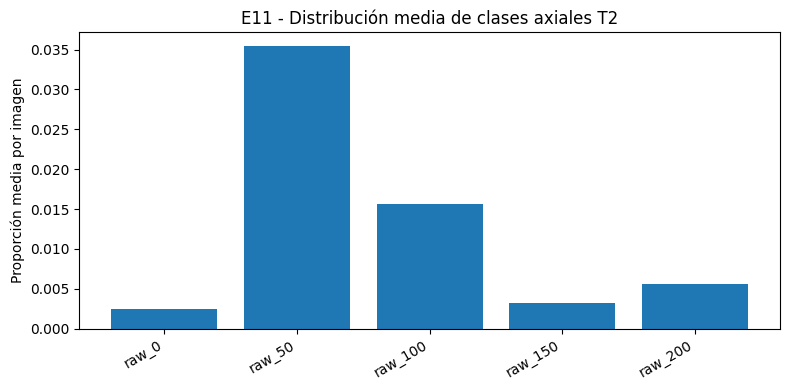

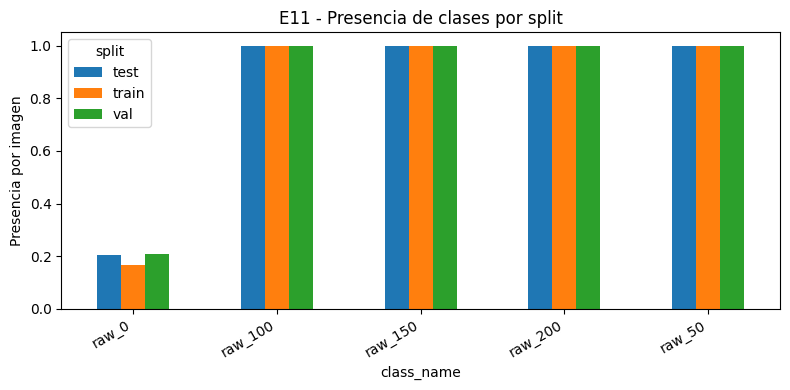

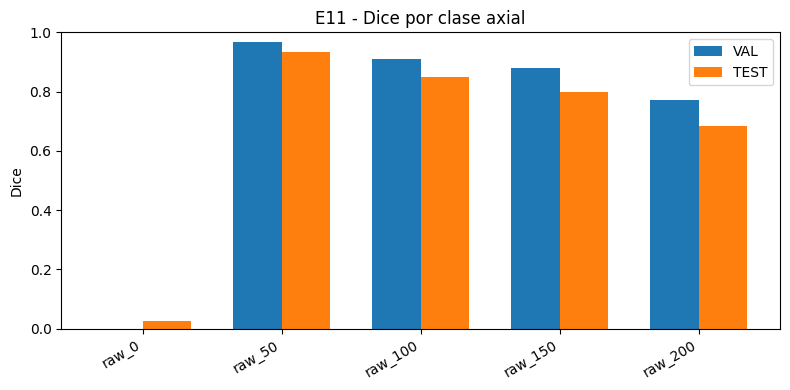

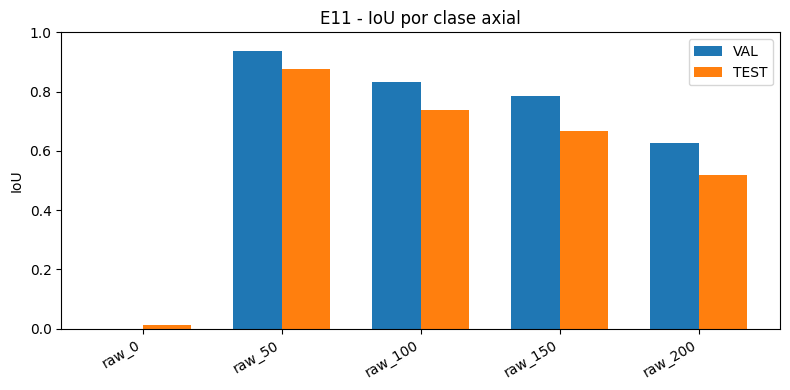

Figuras guardadas en: /content/drive/MyDrive/PFI_MVP/figures


In [8]:
plot_df = dist_summary[dist_summary["class_id"] != 0].copy()

plt.figure(figsize=(8, 4))
plt.bar(plot_df["class_name"], plot_df["mean_ratio"])
plt.ylabel("Proporción media por imagen")
plt.title("E11 - Distribución media de clases axiales T2")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "E11_axial_class_pixel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

presence = by_split[by_split["class_id"] != 0].copy()
pivot_presence = presence.pivot_table(
    index="class_name",
    columns="split",
    values="presence_pct",
)

pivot_presence.plot(kind="bar", figsize=(8, 4))
plt.ylabel("Presencia por imagen")
plt.title("E11 - Presencia de clases por split")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "E11_axial_class_presence_by_split.png", dpi=150, bbox_inches="tight")
plt.show()

m = metrics_by_class[metrics_by_class["class_name"] != "background_250"].copy()
x = np.arange(len(m))
w = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - w / 2, m["dice_val"], width=w, label="VAL")
plt.bar(x + w / 2, m["dice_test"], width=w, label="TEST")
plt.xticks(x, m["class_name"], rotation=30, ha="right")
plt.ylabel("Dice")
plt.ylim(0, 1)
plt.title("E11 - Dice por clase axial")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "E11_axial_dice_by_class_val_test.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(x - w / 2, m["iou_val"], width=w, label="VAL")
plt.bar(x + w / 2, m["iou_test"], width=w, label="TEST")
plt.xticks(x, m["class_name"], rotation=30, ha="right")
plt.ylabel("IoU")
plt.ylim(0, 1)
plt.title("E11 - IoU por clase axial")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "E11_axial_iou_by_class_val_test.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figuras guardadas en:", FIGURES_ROOT)

Reporte final JSON y Markdown

In [9]:
report = {
    "notebook": "19_E11_axial_class_mapping_and_final_report",
    "goal": "document axial T2 class mapping, distribution and final E10 metrics",
    "input_split": str(SPLIT_PATH),
    "input_e10_val_metrics": str(VAL_E10_PATH),
    "input_e10_test_metrics": str(TEST_E10_PATH),
    "n_t2_curated": int(len(split_df)),
    "class_mapping_csv": str(E11_ROOT / "E11_axial_class_mapping.csv"),
    "distribution_summary_csv": str(E11_ROOT / "E11_axial_class_distribution_summary.csv"),
    "distribution_by_split_csv": str(E11_ROOT / "E11_axial_class_distribution_by_split.csv"),
    "metrics_summary_csv": str(E11_ROOT / "E11_axial_metrics_summary.csv"),
    "metrics_by_class_csv": str(E11_ROOT / "E11_axial_metrics_by_class.csv"),
    "key_metrics": {
        "val_dice_macro_no_bg": float(val_metrics["dice_macro_no_bg"]),
        "test_dice_macro_no_bg": float(test_metrics["dice_macro_no_bg"]),
        "val_dice_macro_excluding_raw0": float(val_metrics["dice_macro_excluding_raw0"]),
        "test_dice_macro_excluding_raw0": float(test_metrics["dice_macro_excluding_raw0"]),
    },
    "decision": "axial_t2_module_documented_and_ready_for_multiplanar_pipeline",
}

report_path = E11_ROOT / "E11_axial_final_report.json"
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

md = f"""# E11 - Reporte final del módulo axial T2

## Objetivo

Este reporte documenta el cierre técnico del módulo axial T2 entrenado sobre el dataset Al-Kafri/Sudirman. El objetivo fue dejar trazable el mapeo de clases de los labels finales, la distribución de clases y las métricas finales obtenidas en E10.

## Datos utilizados

- Dataset: Al-Kafri/Sudirman.
- Plano: axial/transversal.
- Modalidad usada para entrenamiento final: T2.
- Labels usados: `05_Final_Ground_Truth_Data/Label_Images/L1_XXXX_DY.png`.
- Pares T2 curados: {len(split_df)}.

## Mapeo de clases

Se conserva la codificación original del label final. El fondo corresponde al valor raw 250. Las clases raw 50, raw 100, raw 150 y raw 200 se consideran clases anatómicas principales codificadas por el dataset. La clase raw 0 se mantiene como clase reportada, pero se considera problemática/minoritaria por su bajo rendimiento relativo.

## Métricas finales E10

- VAL Dice macro sin fondo: {val_metrics["dice_macro_no_bg"]:.4f}
- TEST Dice macro sin fondo: {test_metrics["dice_macro_no_bg"]:.4f}
- VAL Dice macro excluyendo raw_0: {val_metrics["dice_macro_excluding_raw0"]:.4f}
- TEST Dice macro excluyendo raw_0: {test_metrics["dice_macro_excluding_raw0"]:.4f}

## Decisión metodológica

La clase `raw_0` presentó un rendimiento muy bajo en comparación con las clases principales. Por este motivo se reportan dos lecturas: una métrica completa que incluye todas las clases sin fondo y una métrica complementaria excluyendo `raw_0`.

Esta segunda métrica permite interpretar el desempeño del modelo sobre las clases anatómicas principales sin ocultar la existencia de la clase problemática.

## Conclusión

El módulo axial T2 queda documentado como viable para continuar hacia el pipeline multiplanar. La etapa siguiente recomendada es consolidar el modelo sagital final y luego construir un pipeline común de inferencia sagital/axial.
"""

md_path = DOCS_ROOT / "E11_axial_class_mapping_final_report.md"
md_path.write_text(md, encoding="utf-8")

print("Reporte JSON:", report_path)
print("Reporte Markdown:", md_path)
print(json.dumps(report, indent=2, ensure_ascii=False))

Reporte JSON: /content/drive/MyDrive/PFI_MVP/results/E11_axial_class_mapping_final_report/E11_axial_final_report.json
Reporte Markdown: /content/drive/MyDrive/PFI_MVP/docs/E11_axial_class_mapping_final_report.md
{
  "notebook": "19_E11_axial_class_mapping_and_final_report",
  "goal": "document axial T2 class mapping, distribution and final E10 metrics",
  "input_split": "/content/drive/MyDrive/PFI_MVP/results/E9_alkafri_axial_t2_final_labels_baseline/E9_t2_final_labels_curated_split.csv",
  "input_e10_val_metrics": "/content/drive/MyDrive/PFI_MVP/results/E10_axial_t2_final_training_clean/E10_val_metrics.json",
  "input_e10_test_metrics": "/content/drive/MyDrive/PFI_MVP/results/E10_axial_t2_final_training_clean/E10_test_metrics.json",
  "n_t2_curated": 610,
  "class_mapping_csv": "/content/drive/MyDrive/PFI_MVP/results/E11_axial_class_mapping_final_report/E11_axial_class_mapping.csv",
  "distribution_summary_csv": "/content/drive/MyDrive/PFI_MVP/results/E11_axial_class_mapping_final_rep